# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [2]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 33.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.34.0 which is incompatible.


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
kart_data = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/Model Deployment/Project-SuperKart/SuperKart.csv')

# **Data Overview**

In [10]:
# Create a copy of the data
data = kart_data.copy()

In [11]:
# View first 5 rows
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [12]:
# View last 5 rows
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [13]:
# View some randow rows
data.sample(10)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
7405,FD725,17.42,Low Sugar,0.092,Frozen Foods,156.15,OUT003,1999,Medium,Tier 1,Departmental Store,4717.42
6320,FD3103,9.58,Low Sugar,0.030,Canned,131.72,OUT001,1987,High,Tier 2,Supermarket Type1,2446.41
2115,FD694,15.80,Low Sugar,0.090,Baking Goods,183.34,OUT001,1987,High,Tier 2,Supermarket Type1,4907.46
5227,FD5538,11.72,Low Sugar,0.024,Fruits and Vegetables,150.15,OUT004,2009,Medium,Tier 2,Supermarket Type2,3306.30
1880,NC7657,12.00,No Sugar,0.076,Health and Hygiene,152.55,OUT004,2009,Medium,Tier 2,Supermarket Type2,3417.77
5460,NC2775,15.45,No Sugar,0.036,Household,166.22,OUT003,1999,Medium,Tier 1,Departmental Store,4476.99
5431,FD2286,12.29,Low Sugar,0.031,Fruits and Vegetables,126.11,OUT004,2009,Medium,Tier 2,Supermarket Type2,2943.66
7403,FD2515,16.80,Low Sugar,0.017,Seafood,160.69,OUT001,1987,High,Tier 2,Supermarket Type1,4670.70
8393,FD7916,15.94,Low Sugar,0.042,Fruits and Vegetables,190.27,OUT003,1999,Medium,Tier 1,Departmental Store,5081.35
1670,FD3853,11.14,Regular,0.026,Snack Foods,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,3058.90


In [14]:
# checking the shape of the dataset
data.shape

(8763, 12)

* There are 8763 rows and 12 columns in the given dataset.

In [15]:
# Check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


* There are 5 numerical(1 integer & 4 floats) and rest all are of object types.
* All columns have equal number of non-null values(8763) - indicates there are no missing values.

In [16]:
# Checking for duplicate values in the data
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the given dataset.

In [17]:
# Checking for missing values
round(data.isnull().sum() / data.isnull().count() * 100, 2)

,0
Product_Id,0.0
Product_Weight,0.0
Product_Sugar_Content,0.0
Product_Allocated_Area,0.0
Product_Type,0.0
Product_MRP,0.0
Store_Id,0.0
Store_Establishment_Year,0.0
Store_Size,0.0
Store_Location_City_Type,0.0


* There are no missing values in the given dataset.

In [18]:
# Checking statistical summary of the numerical columns in the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


# Observations on numerical columns

* All numerical columns have a count of 8763, which indicates that these variables have complete records and no missing numerical values.

* Product_Weight has a mean of 12.65 and a median of 12.66, which are almost identical. This suggests the distribution is fairly symmetric with no major skewness. The weights range from 4.0 to 22.0.

* Product_Allocated_Area has a mean of 0.0688 and a median of 0.056, with values ranging from 0.004 to 0.298. Since the mean is higher than the median, the variable appears to be slightly right-skewed, meaning a few products are allocated relatively larger display areas compared to most others.

* Product_MRP has a mean of 147.03 and a median of 146.74, which are very close. This suggests that product prices are fairly evenly distributed overall. The MRP ranges from 31 to 266, indicating a moderate spread in product pricing.

* Store_Establishment_Year ranges from 1987 to 2009, showing that the dataset contains both older and relatively newer stores. The median and 75th percentile are both 2009, which suggests that a large number of stores were established in 2009.

* The target variable, Product_Store_Sales_Total, has an average value of 3464.00 and a median of 3452.34, which are very close. This indicates that sales values are reasonably centered and not heavily skewed overall.

* The standard deviation of Product_Store_Sales_Total is 1065.63, which shows that sales vary noticeably across different product-store combinations.

* The sales values range from 33 to 8000, indicating the presence of both very low-selling and very high-selling product-store combinations. This suggests strong variation in sales performance across the dataset.
* Comparing the quartiles of Product_Store_Sales_Total:

  25% of observations are below 2761.72

  50% are below 3452.34

  75% are below 4145.17

  This shows that most sales values are concentrated in a moderate range, with some higher-value observations pushing the upper end.

In [19]:
# Checking statistical summary of categorical columns
data.describe(include="O").T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


## Observations on categorical columns

* All categorical columns also have a count of 8763, which means there are no missing values in these columns.

* Product_Id has 8763 unique values, so it appears to be a unique identifier for each record rather than a repeating category.

* Product_Sugar_Content has 4 categories, and Low Sugar is the most common, appearing 4885 times.

* Product_Type has 16 categories, with Fruits and Vegetables being the most frequent category at 1249 records.

* Store_Id has only 4 unique values, which means the dataset contains data from 4 stores.

* Store_Size has 3 categories, and Medium is the most common store size with 6025 records.

* Store_Location_City_Type has 3 categories, with Tier 2 being the most common city type at 6262 records.

* Store_Type has 4 categories, and Supermarket Type2 appears most frequently with 4676 records.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [ ]:
# - Univariate Analysis (boxplots, distribution plots for important variables)
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

# Univariate Analysis of Numerical Columns

In [ ]:
# List of numerical and categorical columns
num_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
Categorical columns: ['Product_Id', 'Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']



Univariate analysis for: Product_Weight

Univariate analysis for: Product_Allocated_Area

Univariate analysis for: Product_MRP

Univariate analysis for: Store_Establishment_Year

Univariate analysis for: Product_Store_Sales_Total


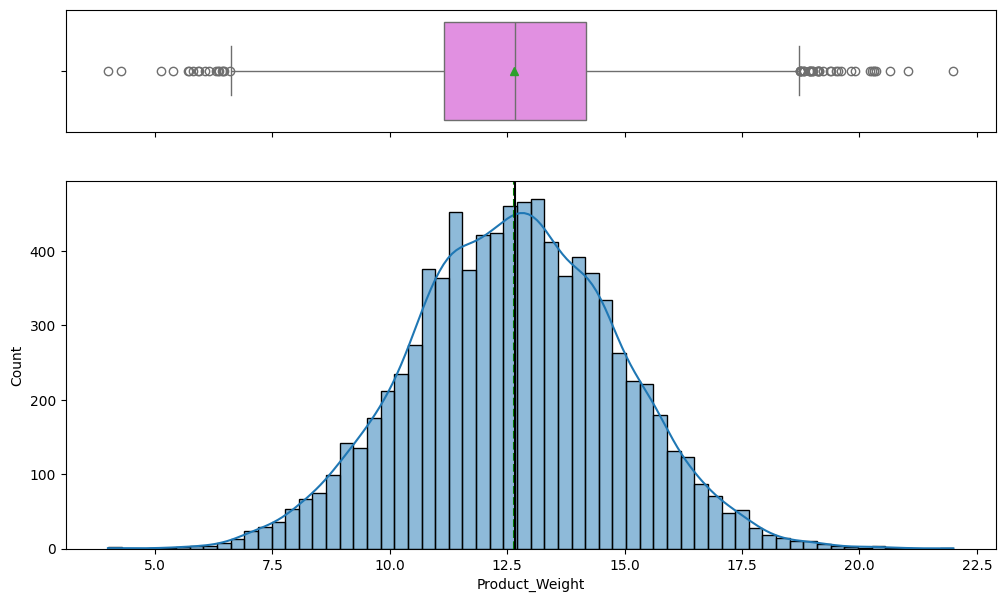

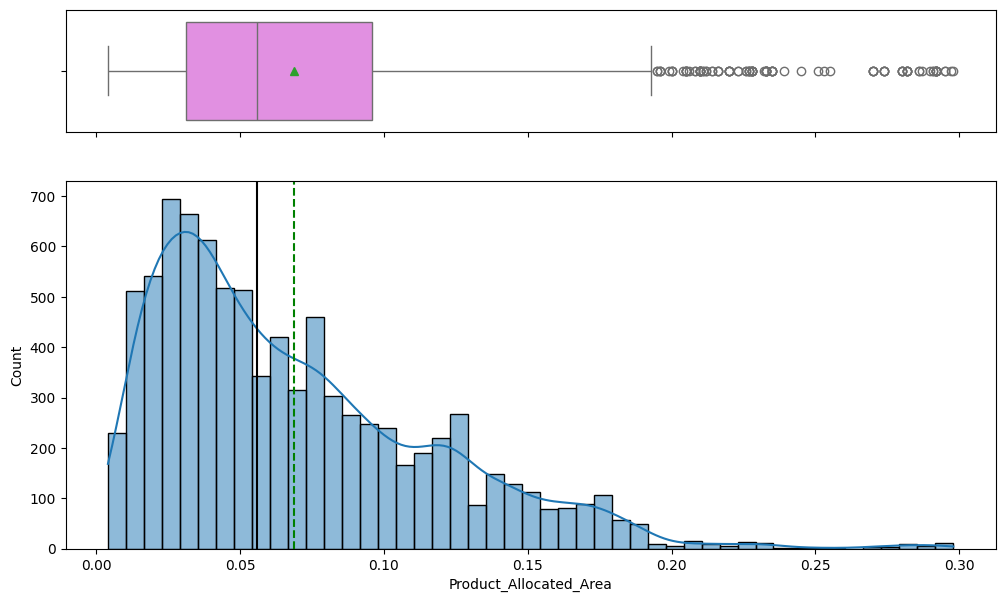

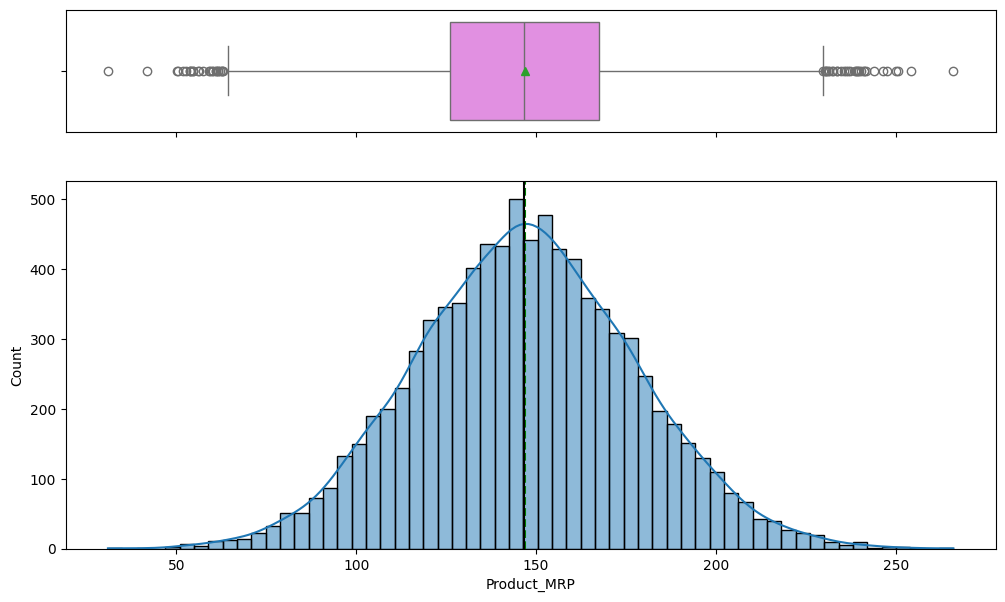

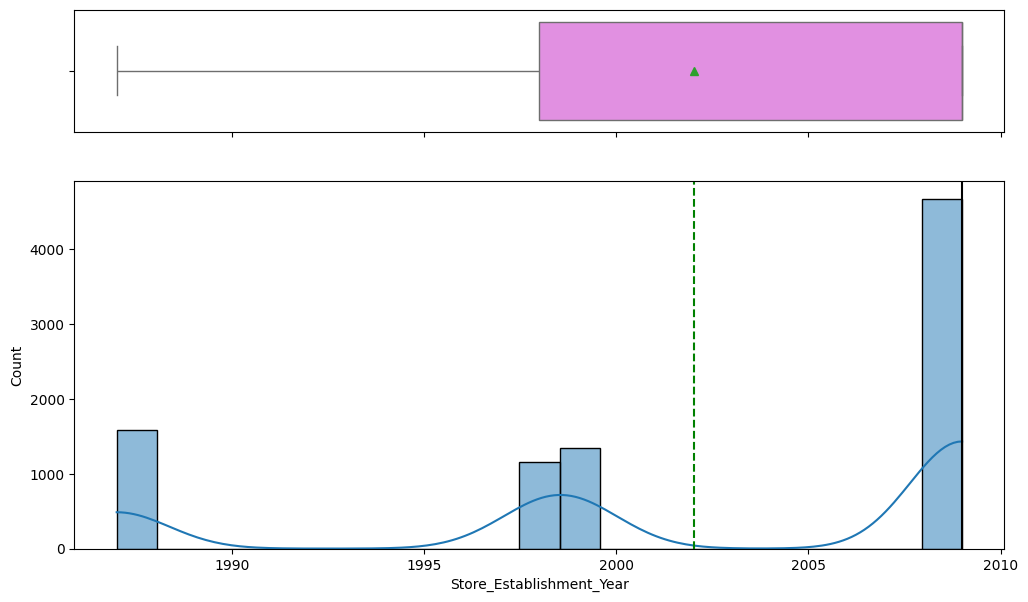

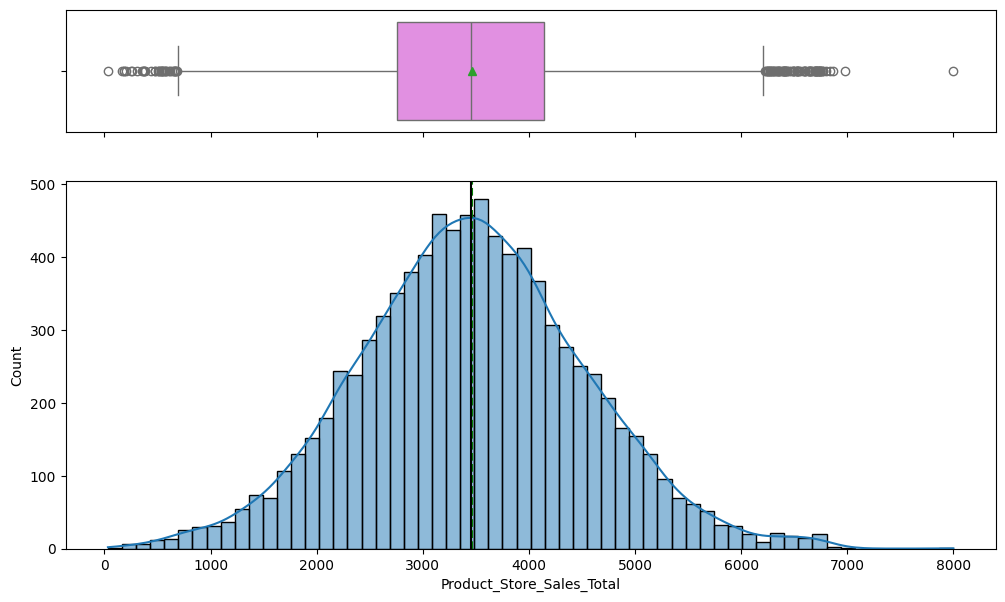

In [ ]:
# Univariate analysis for numerical columns
for col in num_cols:
    print(f"\nUnivariate analysis for: {col}")
    histogram_boxplot(data, col, figsize=(12, 7), kde=True)

# Univariate Analysis Observations For Numerical Columns:

* Product_Weight:
  * The distribution of Product_Weight looks fairly close to a bell-shaped curve, which means most products have weights around the middle range.

  * The mean and median are very close, which suggests that the variable is fairly balanced and does not have strong skewness.

  * Most product weights appear to be concentrated roughly between 10 and 15.

  * There are a few low-weight and high-weight outliers visible in the boxplot, which means some products are much lighter or heavier than the majority.

  * Even though outliers are present, they do not seem to dominate the distribution, as most values are still clustered around the center.

  * Overall, Product_Weight appears to have a fairly normal and well-distributed pattern, with only a small number of unusual values.

* Product_Allocated_Area:

  * The distribution of Product_Allocated_Area is right-skewed, which means most products are given smaller display areas, while a smaller number of products receive much larger shelf space.

  * The mean is higher than the median, which supports the presence of right skewness.

  * Most values are concentrated at the lower end, especially around small allocation ratios.

  * The boxplot shows several high-end outliers, indicating that a few products are allocated much more display space than the majority.

  * Overall, this feature is unevenly distributed, with most products getting limited space and only a few receiving larger display areas.

* Product_MRP

  * The distribution of Product_MRP looks fairly close to a bell-shaped curve, so product prices are spread around a central range.

  * The mean and median are very close, which suggests that product prices are fairly balanced and not strongly skewed.

  * Most product prices seem to fall roughly between 120 and 180.

  * The boxplot shows some low-price and high-price outliers, meaning a few products are priced much lower or higher than most others.

  * Overall, Product_MRP appears to be well distributed, with moderate variation across products.

* Store_Establishment_Year

  * This variable does not follow a smooth distribution, because store establishment year takes only a few distinct year values.

  * Most stores seem to be concentrated in the more recent years, especially around 2009, which matches the earlier statistical summary.

  * There are fewer stores from older years such as 1987 and 1998/1999 compared to the newest group.

  * Since this is a year-based feature with only a few unique values, it behaves more like a grouped/discrete variable than a continuous one.

  * This suggests that the dataset contains a mix of older and newer stores, but newer stores appear more common.

* Product_Store_Sales_Total

  * The distribution of Product_Store_Sales_Total looks fairly close to a bell-shaped curve, so sales are centered around a middle range.

  * The mean and median are very close, which suggests that the sales values are not heavily skewed overall.

  * Most sales values seem to be concentrated roughly between 2500 and 4500.

  * The boxplot shows outliers on both the lower and higher ends, meaning a few product-store combinations have unusually low or unusually high sales.

  * Overall, sales vary across observations, but the majority of values lie in a moderate and fairly balanced range.


Univariate analysis for: Product_Sugar_Content


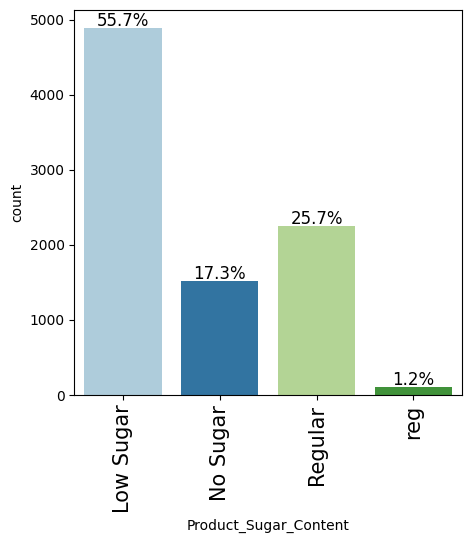


Univariate analysis for: Product_Type


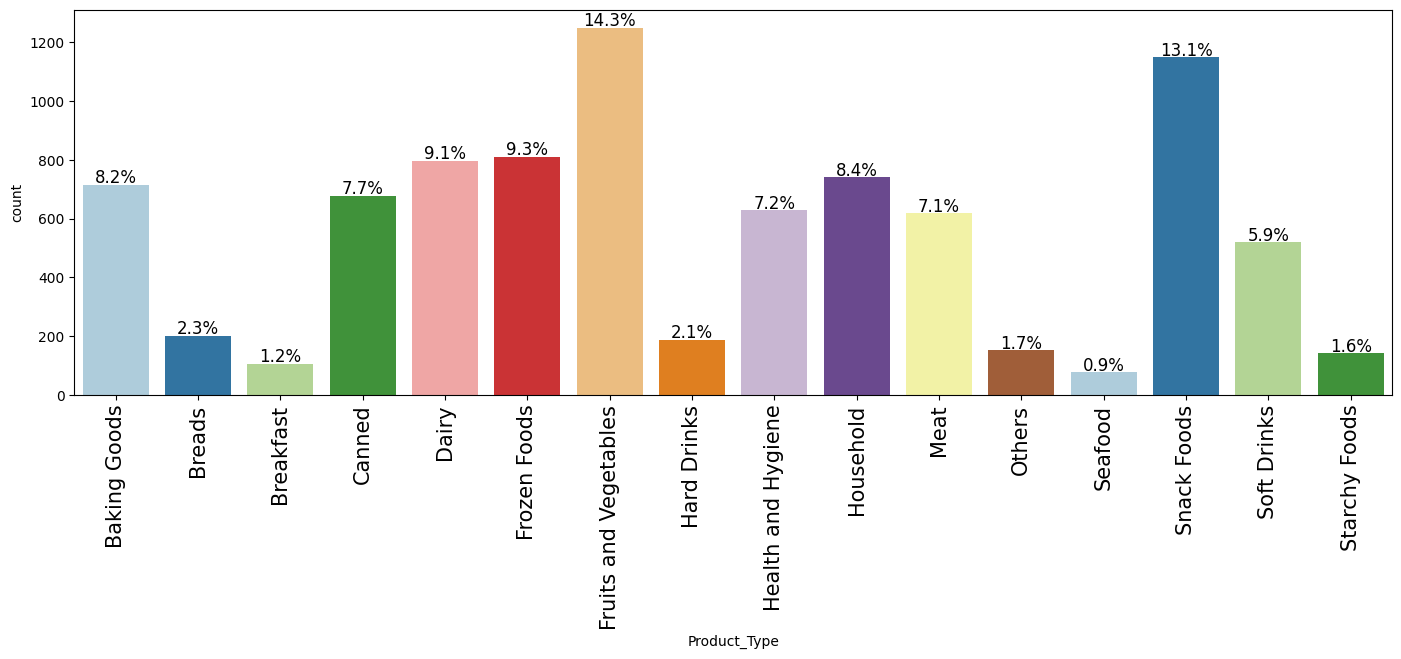


Univariate analysis for: Store_Size


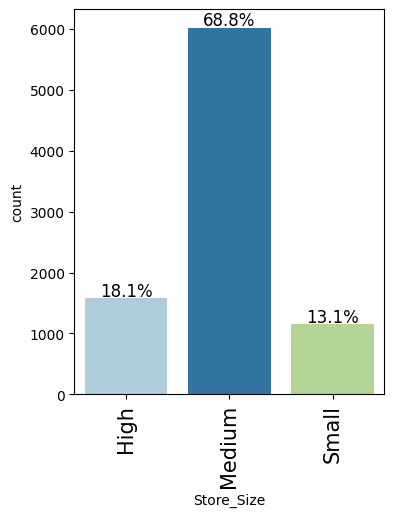


Univariate analysis for: Store_Location_City_Type


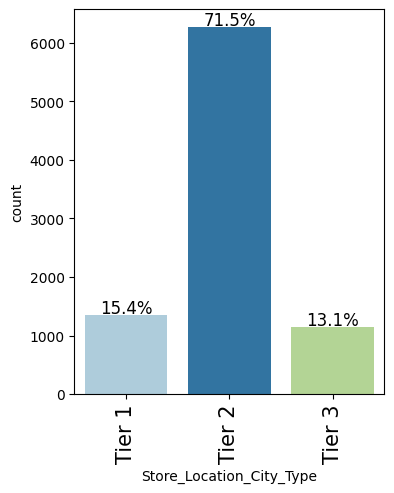


Univariate analysis for: Store_Type


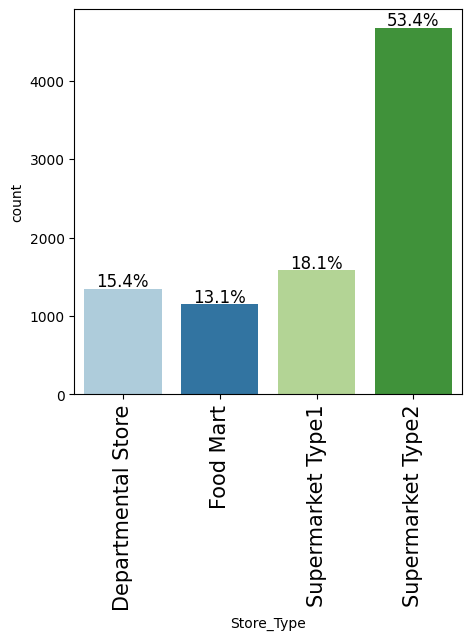

In [ ]:
# Categorical columns excluding ID columnsa as they do not add much value
cat_cols_no_id = [col for col in cat_cols if col not in ["Product_Id", "Store_Id"]]

for col in cat_cols_no_id:
    print(f"\nUnivariate analysis for: {col}")
    labeled_barplot(data, col, perc=True)

# Univariate Analysis Observations For Categorical Columns:

* Product_Sugar_Content

  * Low Sugar is the most common category, making up 55.7% of the dataset.

  * It is followed by Regular (25.7%) and No Sugar (17.3%).

  * There is also a very small category labeled "reg" (1.2%), which looks like it may be a data entry inconsistency for Regular.

  * This suggests that the sugar content column may need a small data cleaning step before model building.

* Product_Type

  * The dataset contains a wide variety of product categories, with 16 different product types.

  * The most common product types are Fruits and Vegetables (14.3%) and Snack Foods (13.1%).

  * Categories such as Frozen Foods, Dairy, Household, Baking Goods, Canned, and Meat also have a noticeable presence.

  * Some product types such as Seafood, Breakfast, Starchy Foods, and Others have very low representation in the dataset.

  * Overall, the product mix is fairly diverse, but a few categories make up a larger share than the rest.
  
* Store_Size

  * Medium-sized stores are the most common, representing 68.8% of the dataset.

  * High-sized stores account for 18.1%, while Small-sized stores make up 13.1%.

  * This suggests that most observations come from medium-sized stores, so the data is not evenly distributed across store sizes.

* Store_Location_City_Type

  * Most stores are located in Tier 2 cities, which account for 71.5% of the data.

  * Tier 1 and Tier 3 cities have much smaller representation at 15.4% and 13.1%, respectively.

  * This means the dataset is heavily concentrated in Tier 2 locations.

* Store_Type

  * Supermarket Type2 is the most common store type, making up 53.4% of the dataset.

  * The other store types have much smaller shares: Supermarket Type1 (18.1%), Departmental Store (15.4%), and Food Mart (13.1%).

  * This shows that the dataset is dominated by Supermarket Type2 stores.


## Bivariate Analysis

# Relationship Among Numerical Variables

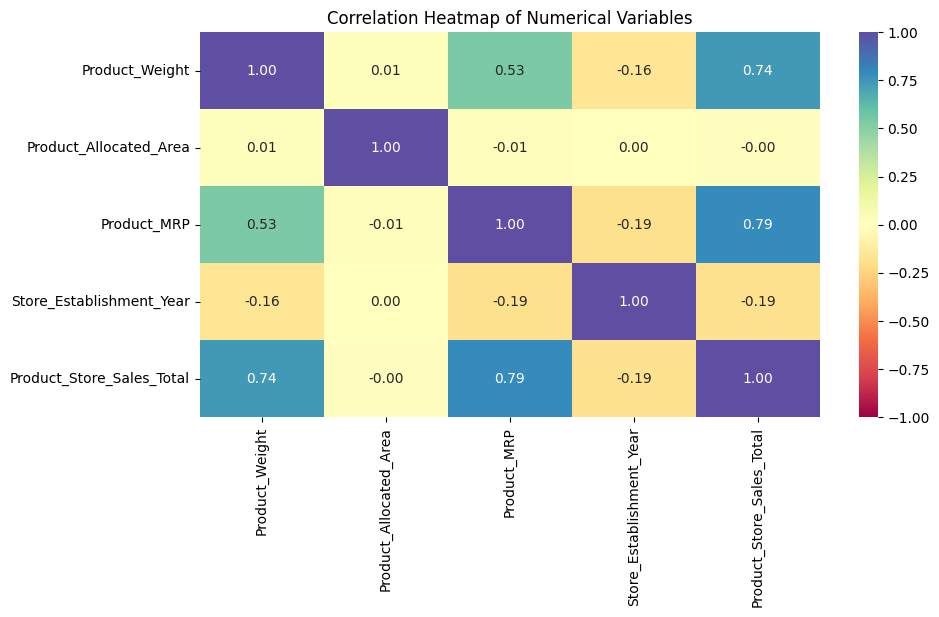

In [ ]:
# Numerical columns
num_cols = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[num_cols].corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="Spectral"
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

#### Observations

* Product_MRP has the strongest positive relationship with Product_Store_Sales_Total at 0.79. This means products with higher prices tend to generate higher sales revenue.

* Product_Weight also shows a strong positive relationship with sales at 0.74. This suggests that heavier products are generally associated with higher sales value.

* Product_Allocated_Area has almost no relationship with sales, with correlation close to 0. This means the display area allocated to a product does not show a clear linear impact on sales in this dataset.

* Store_Establishment_Year has a weak negative relationship with sales at -0.19. This suggests that newer stores may be generating slightly lower sales compared to older stores, but the relationship is not strong.

* There is also a moderate positive relationship between Product_Weight and Product_MRP at 0.53, which means heavier products also tend to be priced higher.

* Most other relationships among the numerical variables are weak, showing that the variables are not highly correlated with one another.

* Overall, Product_MRP and Product_Weight appear to be the most important numerical features for predicting sales.

# Relationship Between Numerical Variables and Target Variable

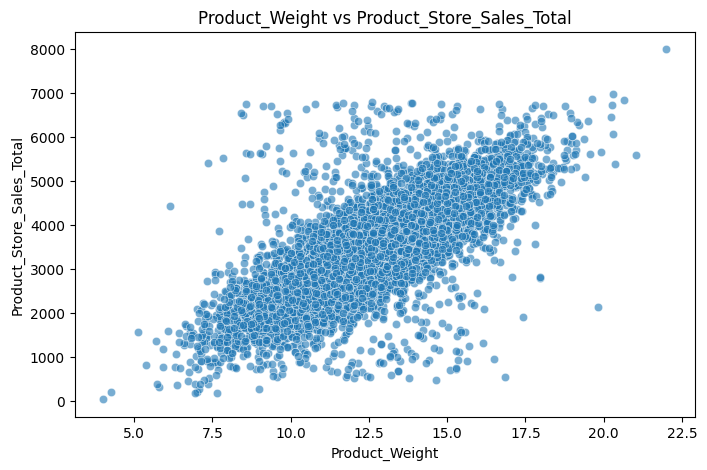

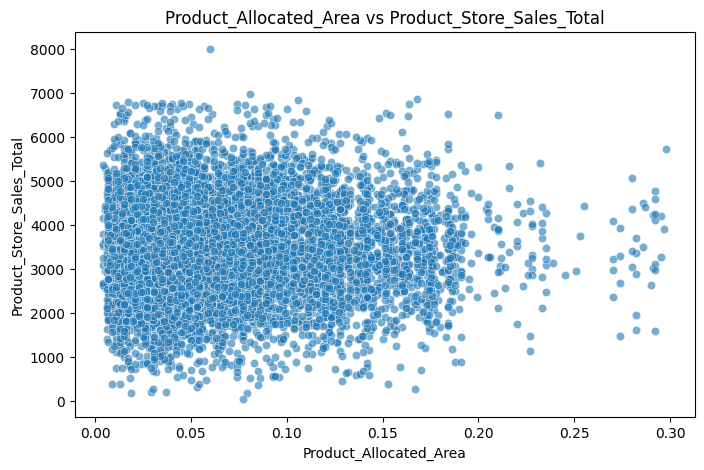

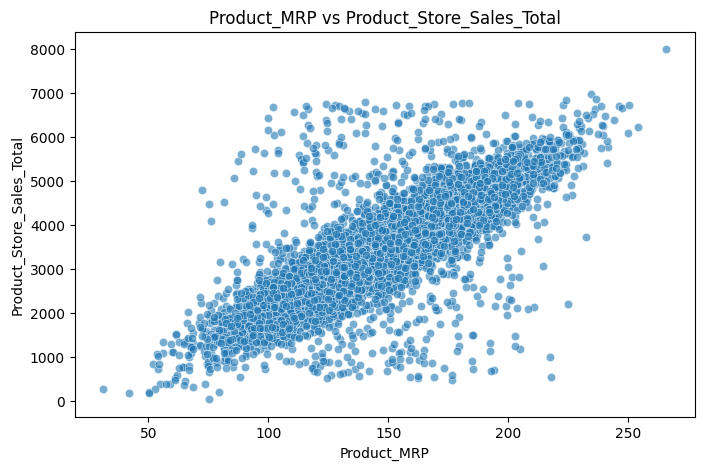

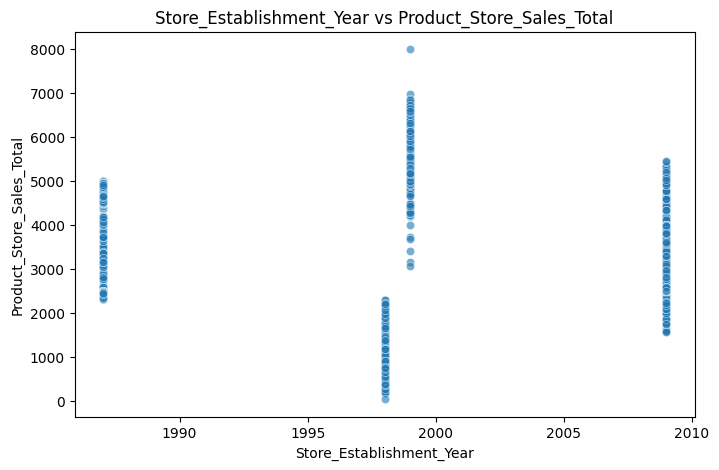

In [ ]:
target = "Product_Store_Sales_Total"

num_features = [col for col in num_cols if col != target]

for col in num_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=data, x=col, y=target, alpha=0.6)
    plt.title(f"{col} vs {target}")
    plt.show()

#### Observations

* Product_Weight vs Product_Store_Sales_Total

  * There is a noticeable upward trend, which means heavier products tend to generate higher sales.

  * Most observations are concentrated in the middle range, with a few unusually high sales values.

* Product_MRP vs Product_Store_Sales_Total

  * This plot shows the strongest upward pattern among the numerical features.

  * As MRP increases, sales revenue also increases clearly.

  * This suggests product price is a very important factor in predicting sales.

* Product_Allocated_Area vs Product_Store_Sales_Total

  * The points are spread out without a strong trend.

  * Sales values appear across almost the full range even for smaller allocated areas.

  * This suggests allocated display area alone may not explain sales well.

* Store_Establishment_Year vs Product_Store_Sales_Total

  * Since the year takes only a few values, the plot appears in vertical bands rather than a continuous trend.

  * There is no strong visible pattern, which supports the earlier finding that this feature has only a weak relationship with sales.

# Relationship Between Categorical Variables and Target Variable

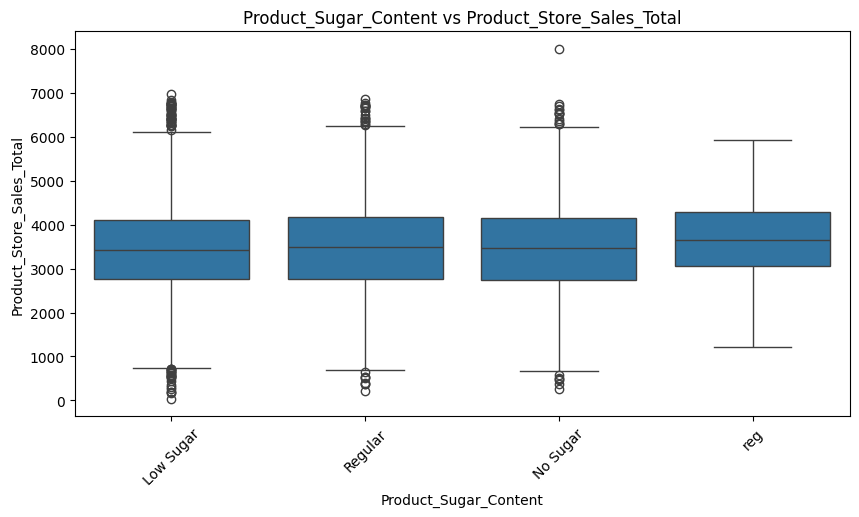

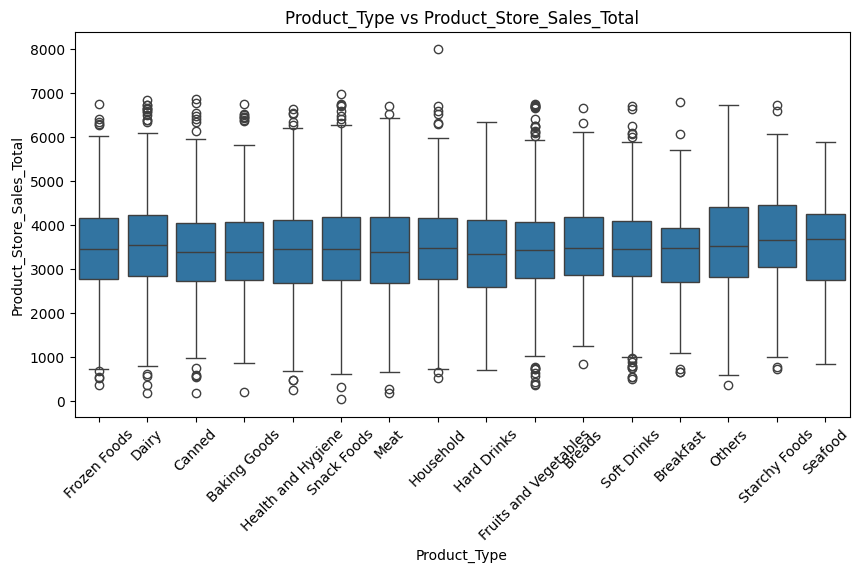

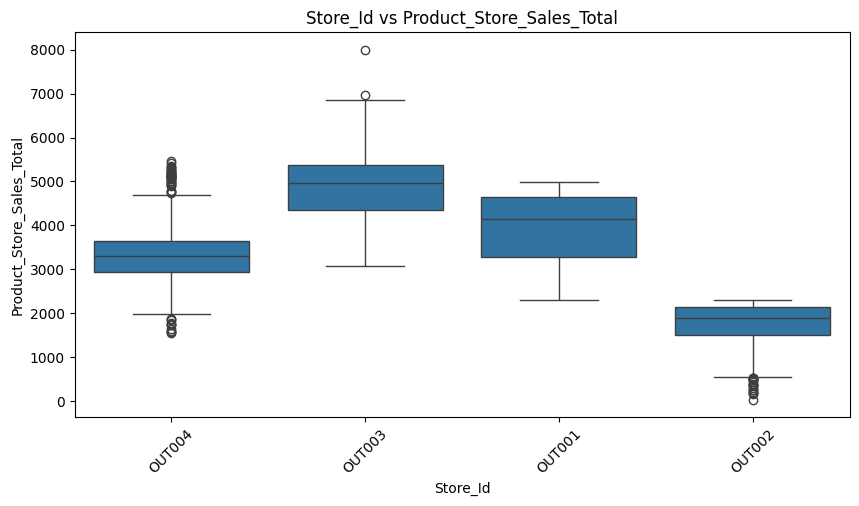

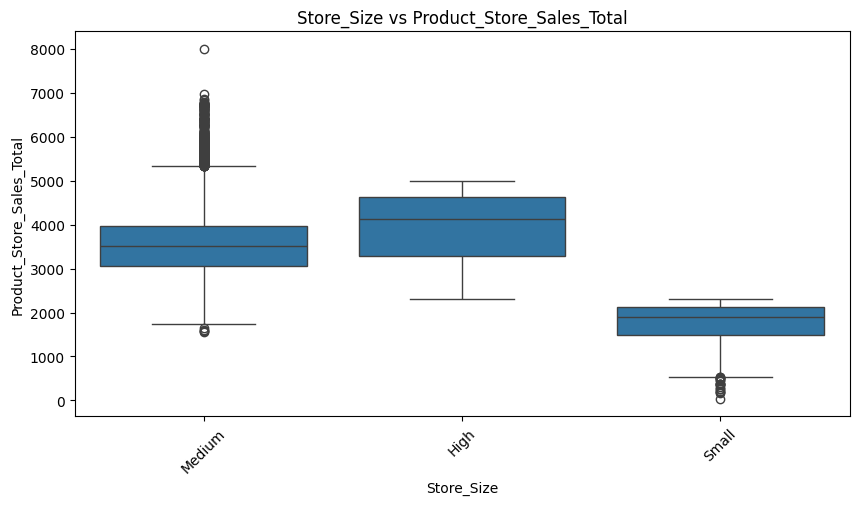

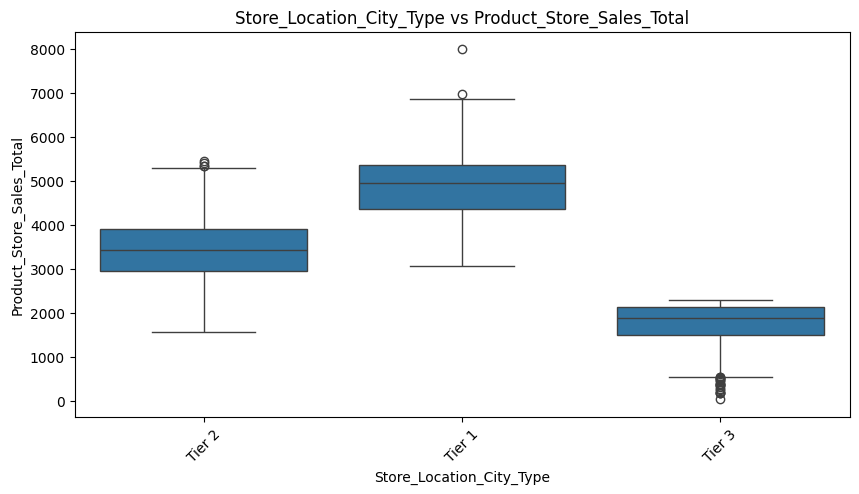

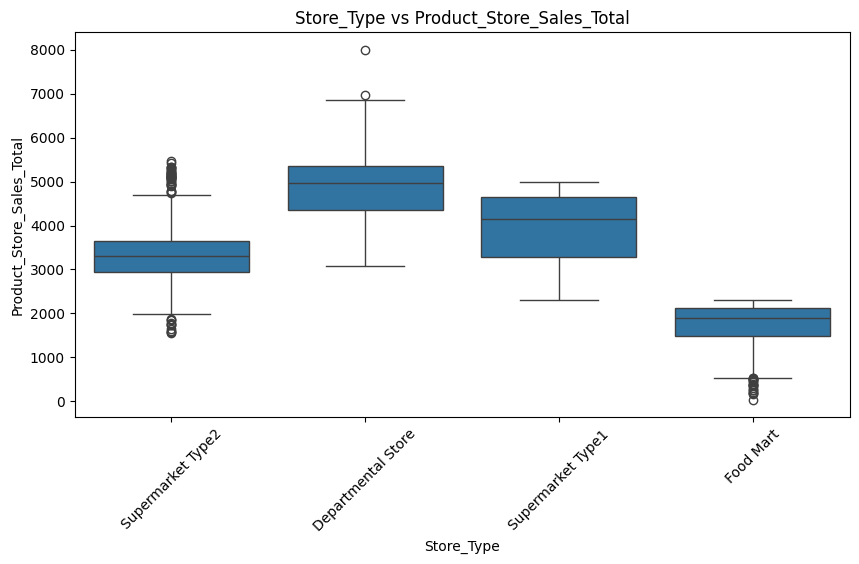

In [ ]:
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()

# Excluding Product_Id because it is an identifier
cat_features = [col for col in cat_cols if col != "Product_Id"]

for col in cat_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=data, x=col, y=target)
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()

#### Observations

* Product_Sugar_Content vs Product_Store_Sales_Total

  * The sales distributions for Low Sugar, Regular, and No Sugar look quite similar.

  * The “reg” category appears to have slightly higher sales, but it has very few observations and likely represents a labeling issue rather than a true business pattern.

  * This suggests that sugar content does not seem to create a major difference in sales.

  * It also confirms that the reg label should be cleaned and merged with Regular before modeling.

* Product_Type vs Product_Store_Sales_Total

  * Most product types have fairly similar sales ranges, so product category alone may not create very large differences in sales.

  * Still, categories like Starchy Foods, Seafood, and Others appear to have slightly higher median sales compared to several other product types.

  * Categories such as Breakfast, Soft Drinks, and Hard Drinks appear relatively lower in comparison.

  * The spread of sales is wide across many product types, which means performance varies even within the same category.

  * Overall, Product_Type has some influence on sales, but the differences are not as strong as those seen for store-related features.

* Store_Id vs Product_Store_Sales_Total

  * Among the four stores, OUT003 shows the highest sales distribution.

  * OUT001 also performs well, though slightly below OUT003.

  * OUT004 has moderate sales.

  * OUT002 has the lowest sales distribution among all stores.

  * This indicates that sales performance varies clearly from store to store.

* Store_Size vs Product_Store_Sales_Total

  * High-sized stores have the highest median sales.

  * Medium-sized stores show moderate sales and also contain many observations and outliers.

  * Small-sized stores have the lowest sales levels.

  * This suggests that larger stores tend to generate higher revenue.

* Store_Location_City_Type vs Product_Store_Sales_Total

  * Stores in Tier 1 cities show the highest sales levels overall.

  * Tier 2 cities fall in the middle range.

  * Tier 3 cities have the lowest sales distribution.

  * This shows that stores in more developed cities tend to generate higher sales.

* Store_Type vs Product_Store_Sales_Total

  * Departmental Store shows the highest median sales among all store types.

  * Supermarket Type1 also has relatively high sales, though slightly lower than Departmental Store.

  * upermarket Type2 has moderate sales compared to the above two.

  * Food Mart has the lowest sales distribution, clearly below the other store types.

  * This suggests that store type has a strong effect on sales performance.


# Relationship Between Important Categorical Variables

## Store Size vs Store Type

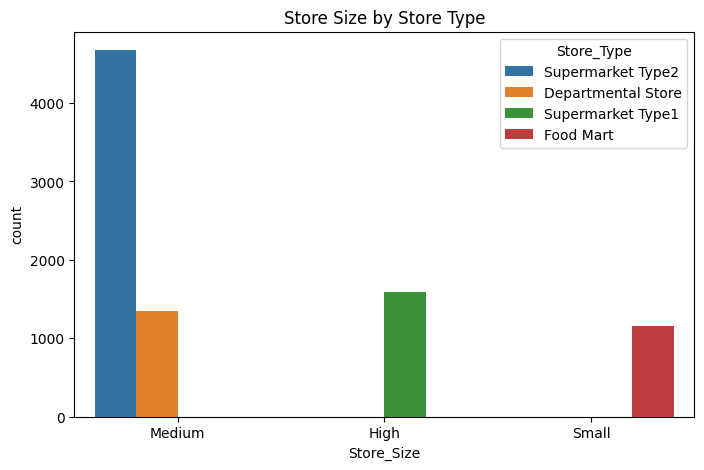

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Store_Size", hue="Store_Type")
plt.title("Store Size by Store Type")
plt.show()

#### Observations

* Supermarket Type2 stores are mostly medium-sized, and this combination has the highest count in the dataset.

* Departmental Stores also appear to be medium-sized.

* Supermarket Type1 stores are mainly high-sized.

* Food Mart stores are mostly small-sized.

* This shows a clear link between store type and store size, meaning certain store types are strongly associated with a particular store size.

* In other words, store size and store type are not independent of each other in this dataset.

## Store Location City Type vs Store Type

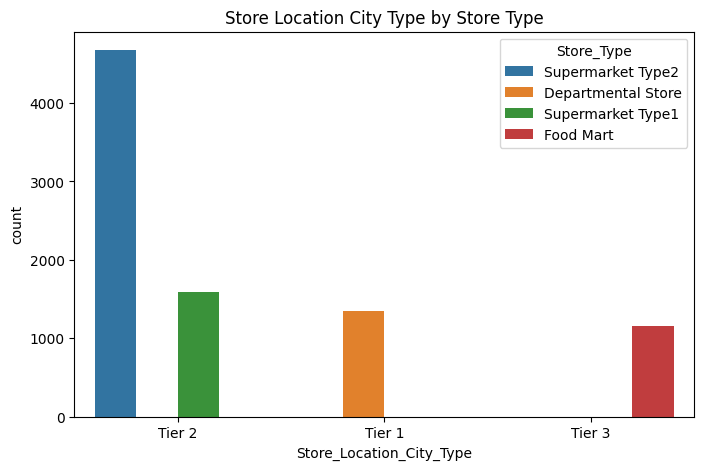

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Store_Location_City_Type", hue="Store_Type")
plt.title("Store Location City Type by Store Type")
plt.show()

#### Observations

* Supermarket Type2 and Supermarket Type1 stores are mainly located in Tier 2 cities.

* Departmental Stores are mainly located in Tier 1 cities.

* Food Mart stores are mainly located in Tier 3 cities.

* This shows a clear connection between store type and city tier, meaning different store formats are concentrated in different types of cities.

* In simple terms, the business seems to place:

  * larger supermarket formats mostly in Tier 2

  * departmental stores in Tier 1

  * food marts in Tier 3

* This also explains why store type and city type may both affect sales, since they are closely linked in the dataset.

## Product Type vs Product Sugar Content

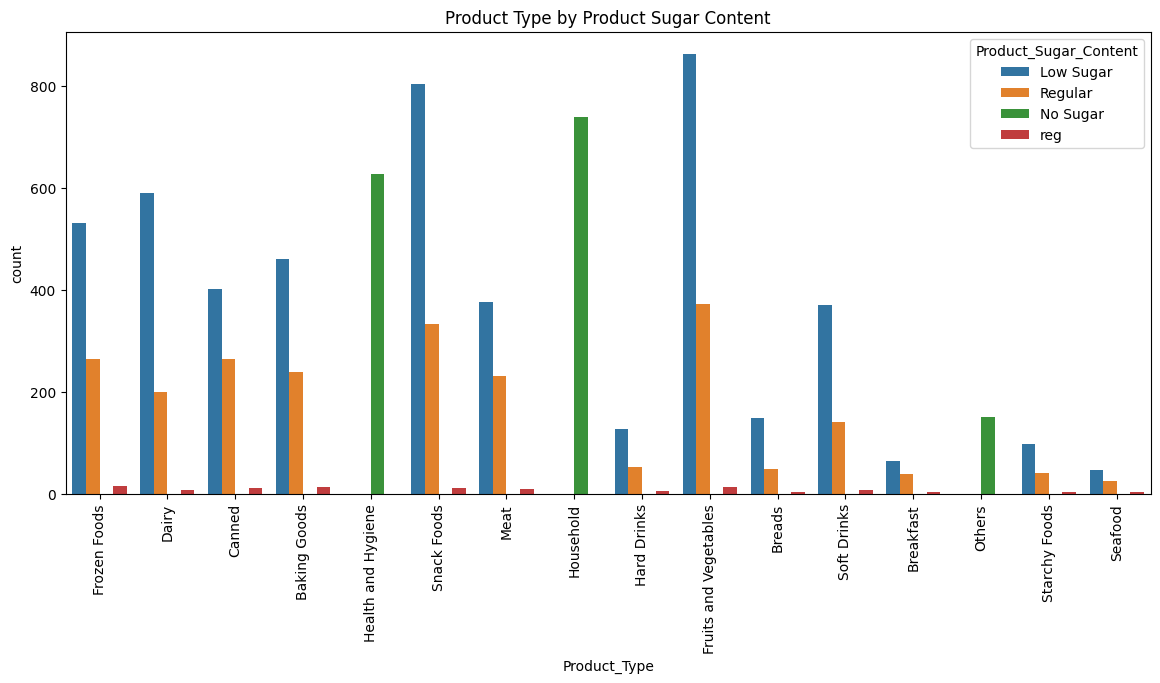

In [ ]:
plt.figure(figsize=(14, 6))
sns.countplot(data=data, x="Product_Type", hue="Product_Sugar_Content")
plt.title("Product Type by Product Sugar Content")
plt.xticks(rotation=90)
plt.show()

#### Observations

* The mix of sugar content is not the same across product types. Different product categories are clearly associated with different sugar-content labels.

* Low Sugar appears most common in many categories such as:

  * Fruits and Vegetables

  * Snack Foods

  * Dairy

  * Frozen Foods

  * Baking Goods

  * Canned

  * Soft Drinks

* No Sugar is especially common in categories like:

  * Household

  * Health and Hygiene

  * Others

* Regular appears in several food and drink categories, but usually in smaller numbers than Low Sugar.

* The reg category appears only in very small counts across product types, which again suggests it is likely a labeling inconsistency rather than a meaningful separate category.

* This plot shows that product type and sugar content are related, so both features may carry useful information for the model.

* It also confirms that the Product_Sugar_Content column should be cleaned by merging reg with Regular before model building.*

# Relationship Between Categorical and Numerical Variables

## Product Type vs Product MRP

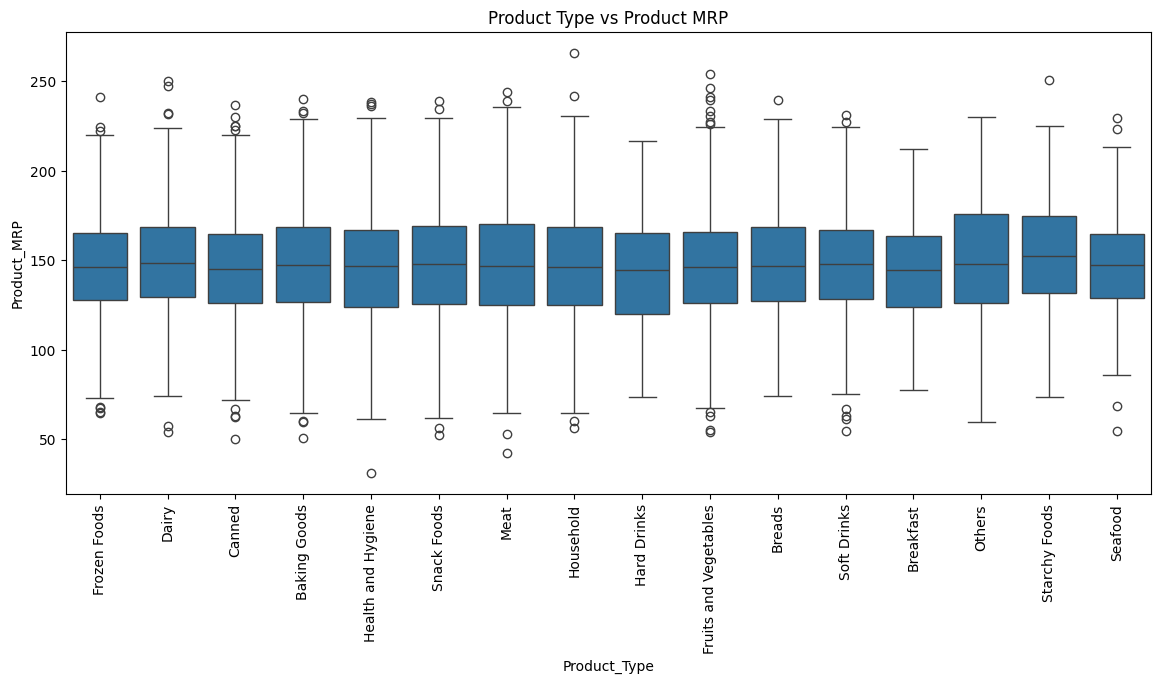

In [ ]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=data, x="Product_Type", y="Product_MRP")
plt.title("Product Type vs Product MRP")
plt.xticks(rotation=90)
plt.show()

#### Observations

* The MRP ranges are fairly similar across most product types, which means product price does not change drastically from one category to another.

* The median MRP for most product types appears to be clustered around a similar middle range, roughly around 140 to 150.

* A few categories such as Starchy Foods, Others, and Dairy seem to have a slightly higher median MRP compared to some other categories.

* Categories like Hard Drinks and Breakfast appear to have a slightly lower median MRP than the rest.

* Almost every product type shows some high-price and low-price outliers, which means there are a few products in each category that are priced much higher or lower than the typical range.

* Overall, Product_Type does have some relationship with MRP, but the differences are not very large. This suggests that price variation exists within categories as well, not just across categories.

# Store Type vs Product Allocated Area

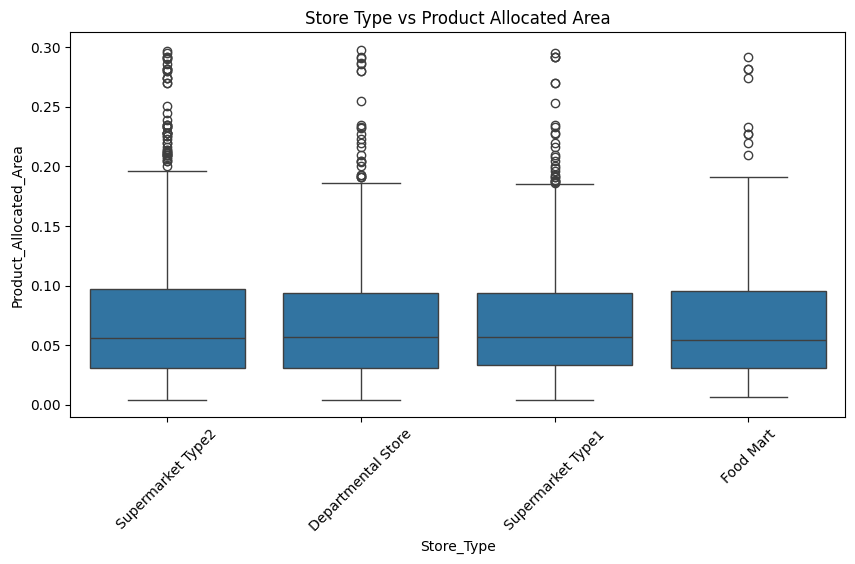

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="Store_Type", y="Product_Allocated_Area")
plt.title("Store Type vs Product Allocated Area")
plt.xticks(rotation=45)
plt.show()

#### Observations

* The allocated area distribution looks very similar across all store types.

* The median allocated area is almost the same for Supermarket Type2, Departmental Store, Supermarket Type1, and Food Mart.

* The spread of values is also quite similar across the different store types, which suggests that store type does not make a big difference in how much display area is allocated to products.

* All store types show several high-value outliers, meaning a few products receive much larger display area than most others, no matter which store type they belong to.

* Overall, this plot suggests that Product_Allocated_Area is fairly consistent across store types, and there is no strong visible relationship between these two variables.

# Product Sugar Content vs Product Weight

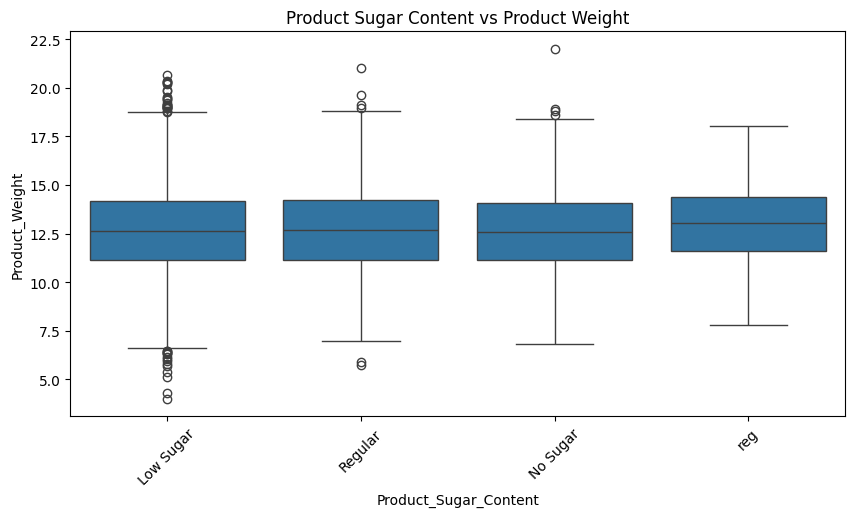

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="Product_Sugar_Content", y="Product_Weight")
plt.title("Product Sugar Content vs Product Weight")
plt.xticks(rotation=45)
plt.show()

#### Observations

* The product weight distribution looks quite similar across all sugar-content categories.

* The median weight for Low Sugar, Regular, and No Sugar is almost the same, which suggests sugar content does not have a strong effect on product weight.

* The reg category appears slightly different, but since it has very few observations, it should not be treated as a meaningful separate group.

* All categories show some outliers on both the lower and higher side, meaning a few products are unusually light or heavy regardless of sugar content.

* Overall, there is no strong visible relationship between sugar content and product weight.

* This plot also supports the need to merge reg with Regular during preprocessing.

#### Insights Based on EDA

* The dataset is clean and complete, with no missing values and no duplicate records. This reduces the amount of data cleaning needed before model building.

* The dataset contains a mix of numerical and categorical features, with product-related and store-related attributes both likely contributing to sales performance.

* Among the numerical features, Product_MRP and Product_Weight show the strongest relationship with Product_Store_Sales_Total. This suggests that higher-priced and heavier products tend to generate higher sales revenue.

* Product_Allocated_Area does not show a strong relationship with sales. This means the amount of shelf/display space alone may not be a major driver of revenue in this dataset.

* Store_Establishment_Year has only a weak relationship with sales, so store age may have some effect, but it does not appear to be one of the strongest predictors.

* Several numerical variables, especially Product_Weight, Product_MRP, and Product_Store_Sales_Total, contain outliers. However, these may represent genuine business cases rather than data errors, so they should be handled carefully instead of being removed blindly.

* Store-related categorical features show a clear impact on sales:

  * Departmental Stores and Supermarket Type1 generally show higher sales

  * Food Marts show the lowest sales

  * Tier 1 cities show higher sales than Tier 2 and Tier 3

  * High-sized stores perform better than medium and small stores

* Sales performance also varies clearly across individual stores, which means Store_Id may carry useful predictive information.

* Product_Type shows some variation in sales, but the differences are not as strong as those seen in store-related features. This suggests that store characteristics may explain sales better than product category alone.

* The Product_Sugar_Content column contains a data quality issue, where reg appears separately from Regular. This should be corrected during preprocessing.

* Important categorical features are also related to one another:

  * Store Type is strongly linked with Store Size

  * Store Type is also closely linked with City Type

* This means some store characteristics move together and jointly influence sales.

* Overall, the EDA suggests that both product features and store features matter, but Product_MRP, Product_Weight, Store_Type, Store_Size, and Store_Location_City_Type appear to be the most informative variables for predicting sales.

# **Data Preprocessing**

## Feature Engineering

#### 1. Fixing inconsistent labels in Product_Sugar_Content

In [20]:
# Making a copy of the dataset for preprocessing
df = data.copy()

# 1. Fixing inconsistent labels in Product_Sugar_Content
df["Product_Sugar_Content"] = df["Product_Sugar_Content"].replace({"reg": "Regular"})

# Checking updated values
print(df["Product_Sugar_Content"].value_counts())

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64


#### 2. Creating Store_Age from Store_Establishment_Year

This is easier for the model to understand than the raw year.

In [21]:
# 2. Creating Store_Age from Store_Establishment_Year
# Using 2025 as the reference year
df["Store_Age"] = 2025 - df["Store_Establishment_Year"]

# View first few rows
df[["Store_Establishment_Year", "Store_Age"]].head()

,Store_Establishment_Year,Store_Age
0,2009,16
1,1999,26
2,1987,38
3,1987,38
4,1998,27


#### 3. Dropping Store_Establishment_Year after creating Store_Age

This is to avoid keeping two columns that represent almost the same thing

In [22]:
# Dropping Store_Establishment_Year after creating Store_Age
df.drop("Store_Establishment_Year", axis=1, inplace=True)

# Check columns
df.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Size', 'Store_Location_City_Type', 'Store_Type',
       'Product_Store_Sales_Total', 'Store_Age'],
      dtype='object')

#### Observations / Rationale

* A small amount of feature engineering was done to improve data quality and make the variables more useful for modeling.

* The value reg in Product_Sugar_Content was merged with Regular because both represent the same category.

* A new feature called Store_Age was created from Store_Establishment_Year. This is more meaningful because store age is easier to understand and use than the raw establishment year.

* The original Store_Establishment_Year column was dropped after creating Store_Age to avoid keeping two columns that carry almost the same information.

* No further feature engineering was needed because the dataset already contains relevant product and store-related variables.

## Outlier Detection and Treatment


In [23]:
# Numerical columns from processed dataset
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

num_cols

['Product_Weight',
 'Product_Allocated_Area',
 'Product_MRP',
 'Product_Store_Sales_Total',
 'Store_Age']

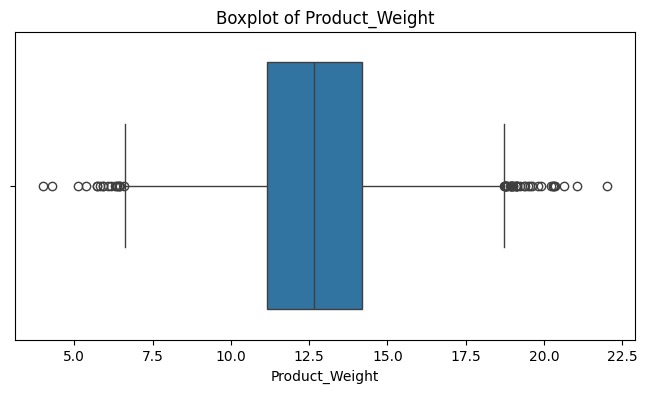

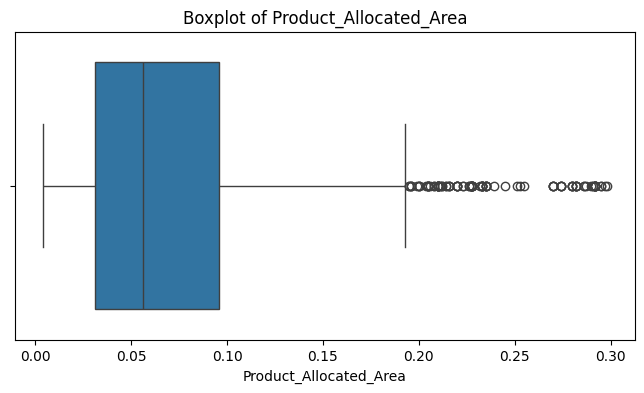

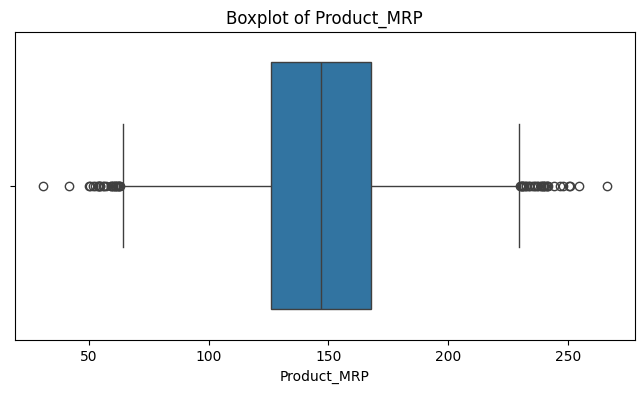

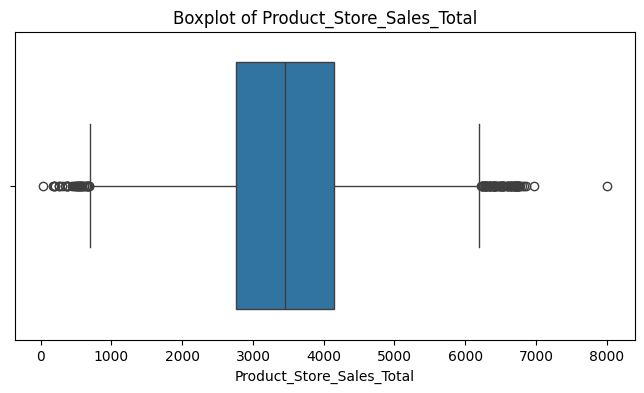

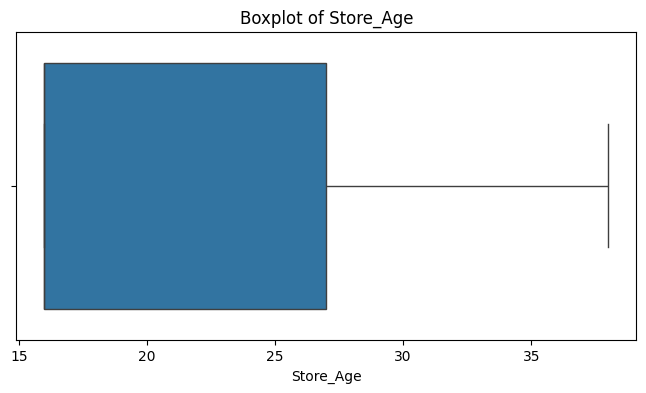

In [ ]:
# Boxplots for numerical columns to inspect outliers
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Observations / Rationale

* Outliers are visible in a few numerical columns such as Product_Weight, Product_Allocated_Area, Product_MRP, and Product_Store_Sales_Total.

* These outliers do not appear to be obvious data entry errors. They may represent genuine business situations, such as premium-priced products, heavier products, or product-store combinations with unusually high sales.

* Removing or capping these values may lead to loss of useful business information, so the outliers were retained for modeling.

## Data Preparation for Modeling

#### Dropping unnecessary column

In [24]:
# Dropping identifier column
df.drop(["Product_Id"], axis=1, inplace=True)

# Check shape
df.shape

(8763, 11)

#### Rationale behind not dropping "Store_Id" column

* Although Store_Id is an identifier, it was not dropped from the model because the business objective is to forecast sales across **SuperKart’s existing network of stores**.

* Different stores may show different sales patterns even when they have similar characteristics such as store size, store type, city tier, and store age.

* Keeping Store_Id helps the model capture these store-specific patterns, which can improve prediction accuracy for known outlets in the network.

* Since the solution is intended to support decision-making across SuperKart’s current stores, retaining Store_Id is appropriate for this use case.

* However, this also means the model is better suited for existing stores already present in the dataset rather than for completely new unseen stores.

#### Separate features and target

In [25]:
# Separating features and target
X = df.drop("Product_Store_Sales_Total", axis=1)
y = df["Product_Store_Sales_Total"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (8763, 10)
Shape of y: (8763,)


#### Train-test split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6134, 10)
X_test shape: (2629, 10)
y_train shape: (6134,)
y_test shape: (2629,)


#### Observations / Rationale
* The target variable for this project is Product_Store_Sales_Total.
* Product_Id was removed before modeling because it is only a unique identifier and does not carry meaningful predictive information.
* Product_Type and Store_Id were retained because the EDA showed that both product category and individual store differences have some relationship with sales.
* Store_Establishment_Year was not used directly because it had already been converted into Store_Age, which is easier to interpret and more useful for modeling.
* The dataset was then split into training and testing sets in a 70:30 ratio.
* The training set will be used to build and tune the model, while the test set will be used to evaluate model performance on unseen data.

## Defining the Preprocessing Pipeline for Encoding Categorical Features

In [27]:
# Selecting categorical columns from X
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

categorical_features

['Product_Sugar_Content',
 'Product_Type',
 'Store_Id',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type']

In [28]:
# Creating preprocessing pipeline for categorical features
preprocessor = make_column_transformer(
    (Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    remainder="passthrough"
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('pipeline',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Product_Sugar_Content', 'Product_Type',
                                  'Store_Id', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type'])])

## Observations / Rationale for pipeline
* The dataset contains categorical variables, so these need to be converted into a numerical form before model training.
* OneHotEncoder was used to encode categorical features so that the machine learning models can process them correctly.
* handle_unknown="ignore" was used so that the pipeline can safely handle any unseen category values during testing or prediction.
* The remaining numerical columns were passed through without change.
* A preprocessing pipeline was created so that the same transformation steps can be applied consistently during both training and testing.

# **Model Building**

## Define functions for Model Evaluation

In [29]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

## Rationale for choosing below models

* I'm seleting Gradient Boosting Regressor and XGBoost Regressor models for model building because both are strong ensemble boosting methods that usually perform well on structured tabular data like this retail sales dataset.

* These models are able to capture nonlinear relationships between the input features and the target variable, which is important because sales are influenced by a combination of product and store-related factors.

* They also handle mixed types of features well after preprocessing, making them suitable for datasets that contain both numerical and categorical variables.

* Gradient Boosting Regressor is chosen as a strong baseline boosting model from scikit-learn, while XGBoost Regressor was selected because it is an advanced boosting algorithm that often gives high predictive performance on regression problems.

* Since the goal of the project is to achieve accurate sales prediction, these two models are appropriate choices due to their ability to model complex patterns and reduce prediction error effectively.

# Model 1 - Gradient Boosting Regressor

In [30]:
gb_regressor = GradientBoostingRegressor(random_state=42)
gb_regressor = make_pipeline(preprocessor,gb_regressor)
gb_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(random_state=42))])

#### Model performance on Training dataset

In [31]:
gbr_model_train_perf = model_performance_regression(gb_regressor, X_train, y_train)
gbr_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.727203,139.150685,0.926324,0.926204,0.04985


Model Performance on Test dataset

In [32]:
gbr_model_test_perf = model_performance_regression(gb_regressor, X_test, y_test)
gbr_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,320.091871,153.615126,0.910466,0.910124,0.065473


#### Observations on Gradient Boosting Regressor Model Performance
* On the training set, the model gave an RMSE of 288.73 and an R-squared of 0.9263.

* On the test set, the model gave an RMSE of 320.09 and an R-squared of 0.9105.

* The training and test results are fairly close, which suggests that the model is generalizing well and is not showing strong overfitting.

* Overall, this model performs well and explains about 91% of the variation in sales on unseen data.

## Model 2 - XGBoost Regressor

In [33]:
xgb_regressor = XGBRegressor(random_state=42)
xgb_regressor = make_pipeline(preprocessor,xgb_regressor)
xgb_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

#### Model performance on Training dataset

In [34]:
xgb_regressor_model_train_perf = model_performance_regression(xgb_regressor, X_train, y_train)
xgb_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,116.935958,57.611238,0.987915,0.987895,0.01958


#### Model performance on Test dataset

In [35]:
xgb_regressor_model_test_perf = model_performance_regression(xgb_regressor, X_test, y_test)
xgb_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,308.665655,139.046217,0.916744,0.916426,0.057379


#### Observations on XGBoost Regressor Model Performance

* On the training set, the model gave an RMSE of 116.94 and an R-squared of 0.9879.

* On the test set, the model gave an RMSE of 308.67 and an R-squared of 0.9167.

* The test performance is slightly better than Gradient Boosting, since it has a lower test RMSE and a higher test R-squared.

* However, the gap between training and test performance is much larger, which suggests that XGBoost is showing some overfitting compared to Gradient Boosting.

# **Model Performance Improvement - Hyperparameter Tuning**

## Gradient Boosting Regressor - Hyperparameter Tuning

In [36]:
# Create pipeline
gb_tuned = GradientBoostingRegressor(random_state=42)
gb_tuned = make_pipeline(preprocessor, gb_tuned)

# Parameter grid
gb_params = {
    "gradientboostingregressor__n_estimators": [100, 200],
    "gradientboostingregressor__learning_rate": [0.05, 0.1],
    "gradientboostingregressor__subsample": [0.8, 1.0],
    "gradientboostingregressor__max_features": ["sqrt", None],
    "gradientboostingregressor__max_depth": [3, 5]
}

# Grid search using RMSE as the main metric
gb_grid = GridSearchCV(
    estimator=gb_tuned,
    param_grid=gb_params,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

# Fit grid search
gb_grid.fit(X_train, y_train)

# Best tuned model
gb_tuned = gb_grid.best_estimator_

# Best parameters and best CV score
print("Best Parameters for Gradient Boosting Regressor:")
print(gb_grid.best_params_)
print("\nBest CV RMSE:")
print(-gb_grid.best_score_)

Best Parameters for Gradient Boosting Regressor:
{'gradientboostingregressor__learning_rate': 0.05, 'gradientboostingregressor__max_depth': 5, 'gradientboostingregressor__max_features': None, 'gradientboostingregressor__n_estimators': 100, 'gradientboostingregressor__subsample': 1.0}

Best CV RMSE:
291.25614116314614


* Best Parameters for Gradient Boosting Regressor:

{'gradientboostingregressor__learning_rate': 0.05, 'gradientboostingregressor__max_depth': 5, 'gradientboostingregressor__max_features': None, 'gradientboostingregressor__n_estimators': 100, 'gradientboostingregressor__subsample': 1.0}

Best CV RMSE:
291.25614116314614

## Model performance on training dataset

In [37]:
gb_tuned_model_train_perf = model_performance_regression(gb_tuned, X_train, y_train)
gb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,239.797175,102.483076,0.94918,0.949097,0.036526


## Model performance on test dataset

In [38]:
gb_tuned_model_test_perf = model_performance_regression(gb_tuned, X_test, y_test)
gb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,299.190019,128.484936,0.921777,0.921478,0.057923


## Observations on Model Performance

Performance on training set
* On the training data, the tuned Gradient Boosting model achieved an RMSE of 239.80 and an R-squared of 0.9492.
* This shows that the model fits the training data very well and explains about 94.9% of the variation in sales.

Performance on test set
* On the test data, the tuned model achieved an RMSE of 299.19 and an R-squared of 0.9218.
* This means the model also performs strongly on unseen data and explains about 92.2% of the variation in sales.

Train vs test performance
* The training and test results are fairly close, although the training performance is better, which is expected.
* The gap between train and test performance is not very large, so the model does not show severe overfitting.
* The test RMSE is lower than the earlier untuned Gradient Boosting model, which suggests that hyperparameter tuning improved the model’s predictive accuracy.

Conclusion
* The tuned Gradient Boosting Regressor performs very well on both training and test datasets.
* It shows strong predictive power, low prediction error, and good generalization to unseen data.
* Since the test RMSE has decreased and the test R-squared has increased after tuning, the tuning process was effective in improving model performance.
* Overall, the tuned Gradient Boosting model appears to be a strong and stable model for this sales prediction problem.



## XGBoost Regressor - Hyperparameter Tuning

In [39]:
# Create pipeline
xgb_tuned = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)
xgb_tuned = make_pipeline(preprocessor, xgb_tuned)

# Parameter grid
xgb_params = {
    "xgbregressor__n_estimators": [75, 100, 125],
    "xgbregressor__subsample": [0.7, 0.8, 1.0],
    "xgbregressor__gamma": [0, 1, 3],
    "xgbregressor__colsample_bytree": [0.5, 0.7, 1.0],
    "xgbregressor__colsample_bylevel": [0.5, 0.7, 1.0]
}

# Grid search using RMSE as the main metric
xgb_grid = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=xgb_params,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

# Fit grid search
xgb_grid.fit(X_train, y_train)

# Best tuned model
xgb_tuned = xgb_grid.best_estimator_

# Best parameters and best CV score
print("Best Parameters for XGBoost Regressor:")
print(xgb_grid.best_params_)
print("\nBest CV RMSE:")
print(-xgb_grid.best_score_)

Best Parameters for XGBoost Regressor:
{'xgbregressor__colsample_bylevel': 0.5, 'xgbregressor__colsample_bytree': 1.0, 'xgbregressor__gamma': 0, 'xgbregressor__n_estimators': 75, 'xgbregressor__subsample': 1.0}

Best CV RMSE:
302.5975753466193


## Best Parameters for XGBoost Regressor:

{'xgbregressor__colsample_bylevel': 0.5, 'xgbregressor__colsample_bytree': 1.0, 'xgbregressor__gamma': 0, 'xgbregressor__n_estimators': 75, 'xgbregressor__subsample': 1.0}

Best CV RMSE:
302.5975753466193

## Model performance on training dataset

In [40]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,160.703032,74.823086,0.977176,0.977139,0.025624


## Model performance on test dataset

In [41]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
xgb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,311.352131,138.68661,0.915288,0.914965,0.057343


## Observations on Model Performance

Performance on training set
* On the training data, the tuned XGBoost model achieved an RMSE of 160.70 and an R-squared of 0.9772.
* This shows that the model fits the training data extremely well and explains about 97.7% of the variation in sales.
Performance on test set
* On the test data, the tuned model achieved an RMSE of 311.35 and an R-squared of 0.9153.
* This means the model still performs strongly on unseen data and explains about 91.5% of the variation in sales.

Train vs test performance
* The training performance is much better than the test performance, which shows that the model is still slightly overfitting.
* Even after tuning, the gap between train and test performance remains noticeable.
* Compared to the untuned XGBoost model, the test performance did not improve:
    * test RMSE became slightly higher (311.35 vs 308.67)
    * test R-squared became slightly lower (0.9153 vs 0.9167)
    
Conclusion
* The tuned XGBoost Regressor performs very well on the training data and still gives strong results on the test data.
* However, the model continues to show some overfitting, because the training performance is much stronger than the test performance.
* Also, hyperparameter tuning did not improve the test performance in this case. In fact, the untuned XGBoost model performed slightly better on unseen data.
* So, for this project, the tuned XGBoost model is still strong, but the tuning process did not lead to a meaningful improvement in generalization.


# **Model Performance Comparison, Final Model Selection, and Serialization**

## Training performance comparison

In [42]:
models_train_comp_df = pd.concat(
    [
        gbr_model_train_perf.T,
        gb_tuned_model_train_perf.T,
        xgb_regressor_model_train_perf.T,
        xgb_tuned_model_train_perf.T
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Gradient Boosting",
    "Gradient Boosting Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boosting,Gradient Boosting Tuned,XGBoost,XGBoost Tuned
RMSE,288.727203,239.797175,116.935958,160.703032
MAE,139.150685,102.483076,57.611238,74.823086
R-squared,0.926324,0.949180,0.987915,0.977176
Adj. R-squared,0.926204,0.949097,0.987895,0.977139
MAPE,0.049850,0.036526,0.019580,0.025624


## Observations from Training Performance Comparison
* Among all models, the untuned XGBoost shows the best training performance, with the lowest training RMSE (116.94) and the highest training R-squared (0.9879).
* The tuned XGBoost also performs very strongly on the training data, though slightly below the untuned XGBoost.
* The tuned Gradient Boosting performs better on the training set than the untuned Gradient Boosting, which shows that tuning improved its ability to fit the training data.
* Overall, the XGBoost models fit the training data more strongly than the Gradient Boosting models.


## Test performance comparison

In [43]:
models_test_comp_df = pd.concat(
    [
        gbr_model_test_perf.T,
        gb_tuned_model_test_perf.T,
        xgb_regressor_model_test_perf.T,
        xgb_tuned_model_test_perf.T
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Gradient Boosting",
    "Gradient Boosting Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Gradient Boosting,Gradient Boosting Tuned,XGBoost,XGBoost Tuned
RMSE,320.091871,299.190019,308.665655,311.352131
MAE,153.615126,128.484936,139.046217,138.686610
R-squared,0.910466,0.921777,0.916744,0.915288
Adj. R-squared,0.910124,0.921478,0.916426,0.914965
MAPE,0.065473,0.057923,0.057379,0.057343


## Observations from Test Performance Comparison

* On the test set, the tuned Gradient Boosting model performs the best overall.
    * It has the lowest RMSE (299.19)
    * It has the highest R-squared (0.9218)
* The untuned XGBoost is the second-best model on the test set, with RMSE = 308.67 and R-squared = 0.9167.
* The tuned XGBoost does not improve over the untuned XGBoost on the test set. Its test RMSE is slightly higher and its R-squared is slightly lower.
* The untuned Gradient Boosting performs the weakest among the four models on the test set, although it still gives strong results overall.


## Overall Comparison
* Hyperparameter tuning improved the Gradient Boosting model, as seen from the lower test RMSE and higher test R-squared after tuning.
* Hyperparameter tuning did not improve the XGBoost model on unseen data, even though it still performed very well on the training set.
* The XGBoost models appear to fit the training data more aggressively, while the tuned Gradient Boosting model shows a better balance between training and test performance.


## Final Model Selection
* Based on the test set results, the tuned Gradient Boosting Regressor has been selected as the final model.
* It has been chosen because it gives:
    * the lowest test RMSE
    * the highest test R-squared
    * and a better balance between training and testing performance
* This means it not only predicts sales more accurately on unseen data, but also generalizes better than the other models.

## Final Conclusion
* All four models performed well, but the tuned Gradient Boosting Regressor emerged as the best model for this project.
* It achieved the strongest performance on the test set and showed good stability, making it the most suitable choice for final deployment and serialization.



# Serialization

In [44]:
# Creating a folder for storing the files needed for web app deployment
os.makedirs("superkart_backend_files", exist_ok=True)

In [45]:
# Defining the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "superkart_backend_files/superkart_prediction_model_v1_0.joblib"

In [46]:
# Saving the best trained model pipeline using joblib
joblib.dump(gb_tuned, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at superkart_backend_files/superkart_prediction_model_v1_0.joblib


In [47]:
# Loading the saved model pipeline from the file
saved_model = joblib.load("superkart_backend_files/superkart_prediction_model_v1_0.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


Let's try making predictions on the test set using the deserialized model.


In [48]:
# Making predictions using the saved model
y_test_pred_saved = saved_model.predict(X_test)

# View first 10 predictions
y_test_pred_saved[:10]

array([3681.13378662, 5832.80560537, 4596.73753108, 3702.65481506,
       4213.06166808, 3721.6092811 , 4339.17041314, 1722.99681237,
       3524.4097393 , 3386.805358  ])

As we can see, the model can be directly used for making predictions without any retraining.

## Final Conclusion

* The final selected model, tuned Gradient Boosting Regressor, was successfully saved using joblib and loaded back without any issues.
* After loading, the model was able to generate predictions on the test data directly, which confirms that the serialization process worked correctly.
* This means the trained pipeline, including preprocessing and model steps, has been preserved properly and can now be reused without retraining.
* Overall, the model is ready for the next stage of deployment in the backend and frontend applications.


# **Deployment - Backend**

## Flask Web Framework


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Weight             8763 non-null   float64
 1   Product_Sugar_Content      8763 non-null   object 
 2   Product_Allocated_Area     8763 non-null   float64
 3   Product_Type               8763 non-null   object 
 4   Product_MRP                8763 non-null   float64
 5   Store_Id                   8763 non-null   object 
 6   Store_Size                 8763 non-null   object 
 7   Store_Location_City_Type   8763 non-null   object 
 8   Store_Type                 8763 non-null   object 
 9   Product_Store_Sales_Total  8763 non-null   float64
 10  Store_Age                  8763 non-null   int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 753.2+ KB


In [90]:
%%writefile superkart_backend_files/app.py
# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API
import os
import traceback

# Initialize the Flask application
sales_revenue_predictor_api = Flask("SuperKart Sales Revenue Predictor")

print("Current working directory:", os.getcwd())
print("Files in /app:", os.listdir("."))

# Load the trained machine learning model
# model = joblib.load("superkart_backend_files/superkart_prediction_model_v1_0.joblib")
MODEL_PATH = os.path.join(os.path.dirname(__file__), "superkart_prediction_model_v1_0.joblib")
model = joblib.load(MODEL_PATH)

print(model)

REFERENCE_YEAR = 2025

try:
    print("Expected features:", model.feature_names_in_)
except Exception as e:
    print("feature_names_in_ not available:", e)

# Define a route for the home page (GET request)
@sales_revenue_predictor_api.get('/')
def home():
    """
    This function handles GET requests to the root URL ('/') of the API.
    It returns a simple welcome message.
    """
    return "Welcome to the SuperKart Sales Revenue Prediction API!"

# Define an endpoint for single property prediction (POST request)
@sales_revenue_predictor_api.post('/v1/salesrevenue')
def predict_sales_revenue():
    """
    This function handles POST requests to the '/v1/salesrevenue' endpoint.
    It expects a JSON payload containing property details and returns
    the predicted sales revenue as a JSON response.
    """
    try:
      # Get the JSON data from the request body
      property_data = request.get_json()
      print("Received JSON:", property_data)

      # Translate Store_Establishment_Year to store_age
      store_est_year = int(property_data["Store_Establishment_Year"])
      store_age = REFERENCE_YEAR - store_est_year
      print("Computed Store_Age:", store_age)

      # Extract relevant features from the JSON data. The order of the column names matters.
      sample = {
          'Product_Weight': property_data['Product_Weight'],
          'Product_Sugar_Content': property_data['Product_Sugar_Content'],
          'Product_Allocated_Area': property_data['Product_Allocated_Area'],
          'Product_Type': property_data['Product_Type'],
          'Product_MRP': property_data['Product_MRP'],
          'Store_Id': property_data['Store_Id'],
          'Store_Size': property_data['Store_Size'],
          'Store_Location_City_Type': property_data['Store_Location_City_Type'],
          'Store_Type': property_data['Store_Type'],
          'Store_Age': store_age
      }

      print("Sample used for prediction:", sample)

      # Convert the extracted data into a Pandas DataFrame
      input_data = pd.DataFrame([sample])
      print("Input dataframe:", input_data)

      prediction = model.predict(input_data)[0]
      prediction = round(float(prediction), 2)

      return jsonify({'Predicted Sales (in dollars)': prediction})

    except Exception as e:
        error_trace = traceback.format_exc()
        print("Prediction error:", error_trace)
        return jsonify({
            "error": str(e),
            "traceback": error_trace
        }), 500

# -----------------------------
# Batch prediction endpoint
# -----------------------------
@sales_revenue_predictor_api.post('/v1/salesrevenuebatch')
def predict_sales_revenue_batch():
    """
    Expects a CSV file upload under key 'file'.
    Required columns in the CSV:
      Product_Weight, Product_Sugar_Content, Product_Allocated_Area, Product_Type, Product_MRP,
      Store_Id, Store_Establishment_Year, Store_Size, Store_Location_City_Type, Store_Type
    Notes:
      - Extra columns will be ignored.
      - If required columns are missing, returns a clear error.
    Returns:
      JSON with list of predictions (row-wise) and row count.
    """
    try:
        # Get the uploaded CSV file from request
        file = request.files.get("file")
        if file is None:
            return jsonify({"error": "No file found. Please upload a CSV file using key='file'."}), 400

        input_data = pd.read_csv(file)

        required_cols = [
            "Product_Weight",
            "Product_Sugar_Content",
            "Product_Allocated_Area",
            "Product_Type",
            "Product_MRP",
            "Store_Id",
            "Store_Establishment_Year",
            "Store_Size",
            "Store_Location_City_Type",
            "Store_Type"
        ]

        missing = set(required_cols) - set(input_data.columns)
        if missing:
            return jsonify({
                "error": f"Missing required columns: {sorted(list(missing))}",
                "required_columns": required_cols
            }), 400

        # Keep only required columns (ignore extras)
        df = input_data[required_cols].copy()

        # Convert Store_Establishment_Year -> Store_Age (drop establishment year after conversion)
        df["Store_Establishment_Year"] = df["Store_Establishment_Year"].astype(int)
        df["Store_Age"] = REFERENCE_YEAR - df["Store_Establishment_Year"]
        df.drop(columns=["Store_Establishment_Year"], inplace=True)

        # Ensure numeric types
        df["Product_Weight"] = df["Product_Weight"].astype(float)
        df["Product_Allocated_Area"] = df["Product_Allocated_Area"].astype(float)
        df["Product_MRP"] = df["Product_MRP"].astype(float)
        df["Store_Age"] = df["Store_Age"].astype(int)

        # Predict
        preds = model.predict(df).tolist()
        preds = [round(float(p), 2) for p in preds]

        return jsonify({
            "count": len(preds),
            "predictions": preds
        })

    except Exception as e:
        error_trace = traceback.format_exc()
        return jsonify({"error": str(e), "traceback": error_trace}), 500


# Run the Flask application in debug mode if this script is executed directly
if __name__ == '__main__':
    sales_revenue_predictor_api.run(debug=True)

Overwriting superkart_backend_files/app.py


## Dependencies File

In [69]:
%%writefile superkart_backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
seaborn==0.13.2
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.32.3
uvicorn[standard]
streamlit==1.43.2

Overwriting superkart_backend_files/requirements.txt


## Dockerfile

In [70]:
%%writefile superkart_backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:sales_revenue_predictor_api"]

Overwriting superkart_backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

- We are creating a Hugging Face Docker Space for our backend using the Hugging Face Hub API.
- This automates the space creation process and enables seamless deployment of our Flask app.

In [71]:
# Import the login function from the huggingface_hub library
from huggingface_hub import login

# Loging in to my Hugging Face account using my access token
login(token="")

# Import the create_repo function from the huggingface_hub library
from huggingface_hub import create_repo

In [72]:
# Creating the repository for the Hugging Face Space
try:
    create_repo("SuperKartSalesRevenuePredictionBackend",
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker" to create a Docker space
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-69ac77bd-6e9807fc021146c24d7b7115;362e7ecc-9d52-48c8-b1ec-2339b982478d)

You already created this space repo: runtimeRD/SuperKartSalesRevenuePredictionBackend


## Uploading Files to Hugging Face Space (Docker Space)

**Note**: Before running the code below, let's ensure that the serialized ML model has been uploaded in to `superkart_backend_files` folder.

In [91]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi

repo_id = "runtimeRD/SuperKartSalesRevenuePredictionBackend"

# Initialize the API
api = HfApi()

# Upload files stored in the folder called superkart_backend_files(from local to HF space)
api.upload_folder(
    folder_path="/content/superkart_backend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...erkart_prediction_model_v1_0.joblib: 100%|##########|  613kB /  613kB            

CommitInfo(commit_url='https://huggingface.co/spaces/runtimeRD/SuperKartSalesRevenuePredictionBackend/commit/456966e37882675b7c7b73f1e3688f5de0e59092', commit_message='Upload folder using huggingface_hub', commit_description='', oid='456966e37882675b7c7b73f1e3688f5de0e59092', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/runtimeRD/SuperKartSalesRevenuePredictionBackend', endpoint='https://huggingface.co', repo_type='space', repo_id='runtimeRD/SuperKartSalesRevenuePredictionBackend'), pr_revision=None, pr_num=None)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [74]:
# Creating a folder for storing the files needed for frontend UI deployment
os.makedirs("superkart_frontend_files", exist_ok=True)

In [75]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000
Store_Age,8763.0,22.967249,8.388381,16.000,16.000,16.000,27.000,38.000


In [76]:
data.describe(include="O").T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


#### Rationale behind the default values

* For the numeric input fields in the Streamlit app, the median values were used as the default values because they represent a typical middle value from the dataset.

* The median is preferred over the mean because it is less affected by extreme values or outliers, making it a more stable default choice for user input.

* Using median values helps the app open with realistic and representative inputs, so the prediction shown is based on a normal case rather than an unusually low or high one.

* For categorical fields, the most frequent category was used as the default because it represents the most common type of observation in the dataset*

In [92]:
%%writefile superkart_frontend_files/app.py

import streamlit as st
import requests
import pandas as pd

# Set the title of the Streamlit app
st.title("SuperKart Sales Revenue Prediction")

# Section for Online (Single) Prediction
st.subheader("Online Prediction")

# Streamlit UI fields with dataset-based default values (median for numeric, mode for categorical)
# Numeric defaults (medians from df.describe().T)
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66, step=0.01)

Product_Allocated_Area = st.number_input(
    "Product Allocated Area",
    min_value=0.0,
    value=0.056,
    step=0.001,
    format="%.3f"
)

Product_MRP = st.number_input("Product MRP", min_value=0.0, value=146.74, step=1.0)

# Categorical defaults (most frequent/top from describe(include="O").T)
Product_Sugar_Content = st.selectbox(
    "Product Sugar Content",
    ["Low Sugar", "Regular", "No Sugar"],
    index=0  # Low Sugar (mode)
)

Product_Type = st.selectbox(
    "Product Type",
    [
        "Fruits and Vegetables", "Snack Foods", "Dairy", "Frozen Foods", "Canned",
        "Baking Goods", "Meat", "Household", "Soft Drinks", "Hard Drinks",
        "Breads", "Breakfast", "Health and Hygiene", "Starchy Foods", "Seafood", "Others"
    ],
    index=0  # Fruits and Vegetables (mode)
)

Store_Id = st.selectbox(
    "Store Id",
    ["OUT001", "OUT002", "OUT003", "OUT004"],
    index=3  # OUT004 is most frequent
)

Store_Establishment_Year = st.number_input(
    "Store Establishment Year",
    min_value=1987,
    max_value=2009,
    value=2009,
    step=1
)

Store_Size = st.selectbox(
    "Store Size",
    ["Small", "Medium", "High"],
    index=1  # Medium (mode)
)

Store_Location_City_Type = st.selectbox(
    "Store Location City Type",
    ["Tier 1", "Tier 2", "Tier 3"],
    index=1  # Tier 2 (mode)
)

Store_Type = st.selectbox(
    "Store Type",
    ["Departmental Store", "Supermarket Type1", "Supermarket Type2", "Food Mart"],
    index=2  # Supermarket Type2 (mode)
)

# Payload (must match training feature names exactly)
product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_Type": Product_Type,
    "Product_MRP": Product_MRP,
    'Store_Id': Store_Id,
    "Store_Establishment_Year": Store_Establishment_Year,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type
}

# Backend URLs
SINGLE_API_URL = "https://runtimeRD-SuperKartSalesRevenuePredictionBackend.hf.space/v1/salesrevenue"
BATCH_API_URL = "https://runtimeRD-SuperKartSalesRevenuePredictionBackend.hf.space/v1/salesrevenuebatch"

if st.button("Predict", type="primary"):
    try:
        st.write("Payload being sent:", product_data)
        response = requests.post(SINGLE_API_URL, json=product_data, timeout=30)

        if response.status_code == 200:
            result = response.json()
            predicted_sales = result["Predicted Sales (in dollars)"]
            st.success(f"Predicted Store Sales (in dollars): ${predicted_sales:.2f}")
        else:
            st.error("Error in API request")
            st.write("Status code:", response.status_code)
            st.write("Response text:", response.text)

            # Try to show JSON if backend returned JSON
            try:
                st.write("Response JSON:", response.json())
            except Exception:
                st.write("Response is not valid JSON.")

    except requests.exceptions.RequestException as e:
        st.error("Request failed (could not reach backend).")
        st.write("Exception:", str(e))

# Batch Prediction (CSV Upload)
st.divider()
st.subheader("Batch Prediction (Upload CSV)")

st.write("Upload a CSV file with the required columns:")
st.code("""
Product_Weight, Product_Sugar_Content, Product_Allocated_Area, Product_Type, Product_MRP,
Store_Id, Store_Establishment_Year, Store_Size, Store_Location_City_Type, Store_Type
""")

uploaded_file = st.file_uploader("Upload CSV file", type=["csv"])

if uploaded_file is not None:
    if st.button("Run Batch Prediction"):
        try:
            files = {"file": uploaded_file}
            response = requests.post(BATCH_API_URL, files=files, timeout=60)

            if response.status_code == 200:
                result = response.json()
                preds = result["predictions"]
                st.success(f"Batch predictions completed for {result['count']} rows.")

                # Show results
                df_preds = pd.DataFrame({"Predicted Sales (in dollars)": preds})
                st.dataframe(df_preds)

                # Download results
                csv_out = df_preds.to_csv(index=False).encode("utf-8")
                st.download_button(
                    "Download Predictions CSV",
                    data=csv_out,
                    file_name="superkart_batch_predictions.csv",
                    mime="text/csv"
                )

            else:
                st.error("Error in batch API request")
                st.write("Status code:", response.status_code)
                try:
                    st.json(response.json())
                except Exception:
                    st.write("Response text:", response.text)

        except requests.exceptions.RequestException as e:
            st.error("Batch request failed (could not reach backend).")
            st.write("Exception:", str(e))

Overwriting superkart_frontend_files/app.py


## Dependencies File

In [79]:
%%writefile superkart_frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Overwriting superkart_frontend_files/requirements.txt


## DockerFile

In [80]:
%%writefile superkart_frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting superkart_frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [93]:
repo_id = "runtimeRD/Superkart_Salesrevenue_Frontend"

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/superkart_frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

CommitInfo(commit_url='https://huggingface.co/spaces/runtimeRD/Superkart_Salesrevenue_Frontend/commit/77a2fc2da30fc39b7c16fca07ca0f474878601fb', commit_message='Upload folder using huggingface_hub', commit_description='', oid='77a2fc2da30fc39b7c16fca07ca0f474878601fb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/runtimeRD/Superkart_Salesrevenue_Frontend', endpoint='https://huggingface.co', repo_type='space', repo_id='runtimeRD/Superkart_Salesrevenue_Frontend'), pr_revision=None, pr_num=None)

# Sharing the links of my Hugging Face Spaces

Frontend: https://huggingface.co/spaces/runtimeRD/Superkart_Salesrevenue_Frontend

Backend: https://huggingface.co/spaces/runtimeRD/SuperKartSalesRevenuePredictionBackend


# **Actionable Insights and Business Recommendations**

## **Actionable Insights**

1. Product price is one of the strongest drivers of sales revenue:
    * The analysis showed that Product_MRP has a strong positive relationship with Product_Store_Sales_Total. Products with higher MRP generally contribute more to revenue.
2. Product weight also has a meaningful impact on sales:
   * Heavier products were generally associated with higher sales, suggesting that certain larger or higher-value product categories contribute more strongly to revenue.
3. Store-related factors play a major role in sales performance:
   * Features such as Store_Type, Store_Size, Store_Location_City_Type, and Store_Id showed clear differences in sales patterns. This indicates that store format and location characteristics strongly influence revenue.
4. Store age impacts performance and is now handled automatically:
   * Store maturity matters, and the system now derives Store_Age from Store_Establishment_Year inside the backend. This reduces user input errors and keeps the model aligned with how it was trained.
5. Some stores consistently perform better than others:
   * The inclusion of Store_Id improved prediction performance, which suggests that individual outlets have store-specific behavior not fully explained by other features alone.
6. Display area alone is not a strong driver of sales:
   * Product_Allocated_Area did not show a strong direct relationship with sales, which suggests that simply assigning more shelf space may not always guarantee higher revenue.
7. The final tuned Gradient Boosting model delivered the best performance:
   * It achieved the lowest test RMSE and highest test R-squared among all models built, making it the most suitable choice for deployment.

## **Business Recommendations**

1. Focus pricing and assortment strategies on high-revenue product categories:
   * Since product price and product type influence sales strongly, SuperKart should closely monitor which categories and price bands generate the highest revenue and use this to optimize assortment planning.
2. Use store-specific forecasting for inventory planning:
   * Since store-level behavior differs meaningfully, inventory decisions should not be made using a one-size-fits-all approach. Forecasts should be generated separately for each store to better align stock levels with local demand patterns.
3. Prioritize high-performing store formats and locations:
   * Since store type, size, and city tier influence sales, SuperKart can use this insight when planning promotions, stock allocation, and expansion strategies across different outlets.
4. Do not rely only on display area for revenue growth decisions:
   * Since allocated area did not show a strong impact on sales, merchandising decisions should also consider product demand, pricing, and store-specific customer behavior rather than shelf space alone.
5. Integrate the deployed model into regular business planning cycles:
   * Use the model for monthly/quarterly forecasting, inventory planning, and store-level revenue strategy. Since Store_Establishment_Year is now an input, business users can easily simulate scenarios tied to store maturity.
6. Use the current solution for existing stores and consider future enhancement for new-store forecasting:
   * Since Store_Id was retained to improve prediction accuracy for known stores, the current model is best suited for SuperKart’s existing network. As a future enhancement, a second generalized model can be built without Store_Id to better support prediction for completely new unseen stores.
7. Batch prediction is now a key enhancement:
   * Business teams can upload a CSV of many product-store combinations and receive predictions in one run. This enables:
      * bulk scenario planning
      * faster inventory decisions
      * large-scale promo/assortment simulations across stores